In [167]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [ ]:
"""
Here, we define a function:  lorenz(parameters)plt.subplot(3,1,1)
plt.plot(t, X1[0,:], 'r--', label='RK4')
plt.plot(t, Y1[0,:], 'b-', label='Euler')
plt.ylabel('x')
plt.legend()

which returns a vector 
containing the right hand side of Lorenz system
"""

def lorenz(x, sig=10.0, r=28.0, b=8.0/3.0):
    # x is a 3-vector: [x, y, z]
    x1, x2, x3 = x
    return np.array([
        sig*(x2 - x1),
        r*x1 - x2 - x1*x3,
        x1*x2 - b*x3
    ], dtype=float)



In [169]:
# -----------------------
# Euler explicit step
# -----------------------
def euler_step(u, dt, rhs, *rhs_args):
    return u + dt*rhs(u, *rhs_args)



# -----------------------
# RK4 step for x' = f(t, x)
# -----------------------
def rk4_step(u, dt, rhs, *rhs_args):
    k1 = rhs(u,             *rhs_args)
    k2 = rhs(u + 0.5*dt*k1, *rhs_args)
    k3 = rhs(u + 0.5*dt*k2, *rhs_args)
    k4 = rhs(u + dt*k3,     *rhs_args)
    return u + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

Q2. The code for forward euler and rk4 is shown in above cells. 

When x(t), y(t), z(t) are compared between euler and rk4 methods, the solutions by two methods differ significanty. 


It is because Lorenz system is chaotic and it features multi-scale phenomena. Explicit Euler at a relatively large time step size is very inaccurate and often locally unstable. Thus, local errors blow up exponentially and the trajectory separates from RK4 very quickly.

A time step as small as dt = 0.000625 may be affordable in some laptops, but the solutions by two methods may agree only for a small period, such as less than 10 seconds.

Reduction of time step below 1e-5 may help improve the prediction, but the code can be extremely slow. 

Visualization of 3D plot indicates the butterfly effect captured by both methods, but the detailed dynamics differ significantly. 


In [170]:
# -----------------------
# time loop
# -----------------------
t0 = 0.0
dt = 0.000625
T = 100
nsteps = int(T/dt)

# parameters (σ, ρ, β)
sig = 10.0
rho = 28.0
beta = 8.0/3.0

# initial condition
x0 = np.array([1.0, 1.0, 1.0], dtype=float)
t = t0


# Allocate solution array: 3 rows × (nsteps+1) columns
X = np.zeros((3, nsteps+1)) # RK4
Y = np.zeros((3, nsteps+1)) # euler
t_values = np.zeros(nsteps+1)

# Initial values
X[:, 0] = x0
Y[:, 0] = x0
t_values[0] = t0plt.subplot(3,1,1)
plt.plot(t, X1[0,:], 'r--', label='RK4')
plt.plot(t, Y1[0,:], 'b-', label='Euler')
plt.ylabel('x')
plt.legend()


# Time loop
x = x0.copy()
y = x0.copy()
t = t0


for n in range(1, nsteps+1):
    y = euler_step(y, dt, lorenz, sig, rho, beta)
    x = rk4_step(x, dt, lorenz, sig, rho, beta)
    t += dt
    X[:, n] = x # store rk4 sol
    Y[:, n] = y # store euler sol
    t_values[n] = t
    
X.shape, nsteps, t_values[nsteps]

((3, 160001), 160000, np.float64(99.99999999991812))

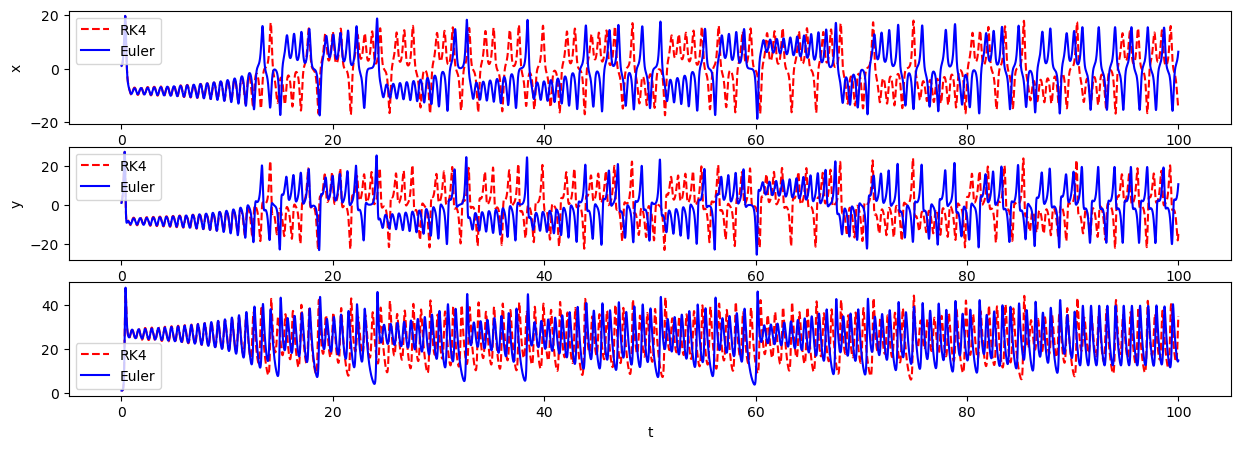

In [171]:
plt.figure(figsize=(15,5))
plt.subplot(3,1,1)
plt.plot(t_values, X[0,:], 'r--', label='RK4')
plt.plot(t_values, Y[0,:], 'b-', label='Euler')
plt.ylabel('x')
plt.legend()

plt.subplot(3,1,2)
plt.ylabel('y')
plt.plot(t_values, X[1,:], 'r--', label='RK4')
plt.plot(t_values, Y[1,:], 'b-', label='Euler')
plt.legend()

plt.subplot(3,1,3)
plt.plot(t_values, X[2,:], 'r--', label='RK4')
plt.plot(t_values, Y[2,:], 'b-', label='Euler')
plt.xlabel('t')
plt.legend()

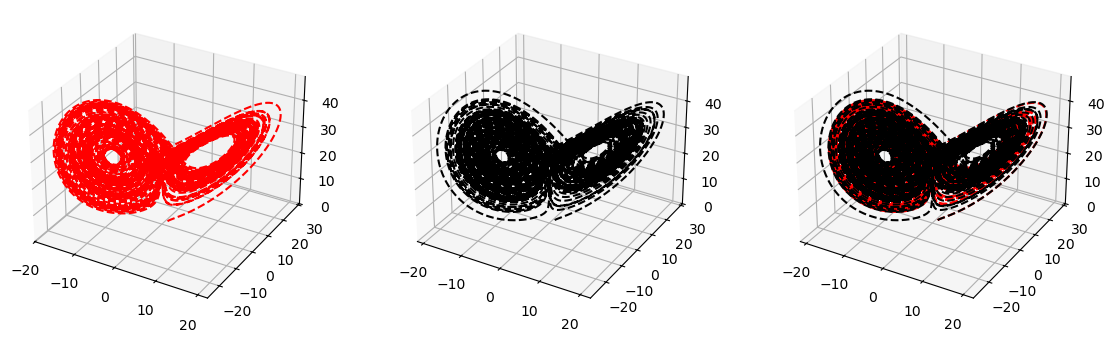

In [172]:
fig = plt.figure(figsize=(14,4))
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(X[0,:], X[1,:], X[2,:],'r--')
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(Y[0,:], Y[1,:], Y[2,:],'k--')
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(X[0,:], X[1,:], X[2,:],'r--')
ax3.plot(Y[0,:], Y[1,:], Y[2,:],'k--')



In [173]:
# ----- settings -----
ntraj  = 100
t0     = 0.0
dt     = 0.01
nsteps = 500

sig  = 10.0
rho  = 28.0
beta = 8.0/3.0

rng = np.random.default_rng()               # set seed for reproducibility
x0s = 30.0*(rng.random((3, ntraj)) - 0.5)    # shape (3, ntraj), in [-15, 15]^3

# ----- allocate -----
X = np.zeros((3, ntraj, nsteps+1), dtype=float)  # variable × traj × time
Y = np.zeros((3, ntraj, nsteps+1), dtype=float)  # variable × traj × time
t_values = np.linspace(t0, t0 + nsteps*dt, nsteps+1)

# place ICs at k=0
X[:, :, 0] = x0s
Y[:, :, 0] = x0s


In [174]:

# ----- integrate each trajectory with Euler -----
for j in range(ntraj):
    x = x0s[:, j].copy()
    y = x0s[:, j].copy()
    for k in range(1, nsteps+1):
        y = euler_step(y, dt, lorenz, sig, rho, beta)
        Y[:, j, k] = y
        x = rk4_step(x, dt, lorenz, sig, rho, beta)
        X[:, j, k] = x

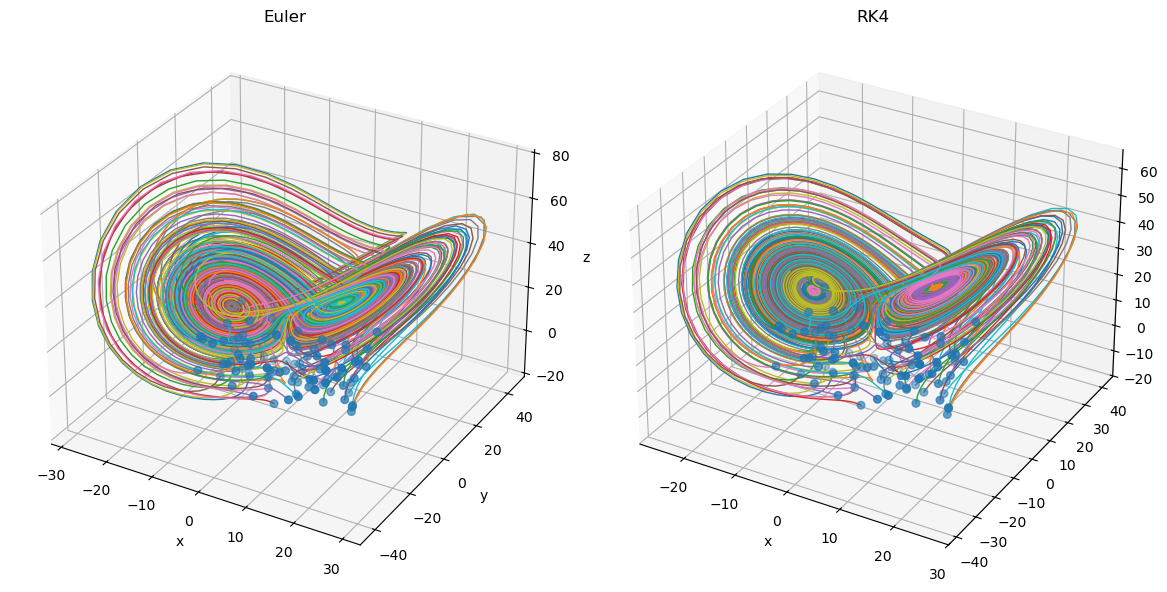

In [175]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection='3d')

# trajectories
for j in range(ntraj):
    ax.plot(Y[0, j, :], Y[1, j, :], Y[2, j, :], linewidth=1)

# initial points
ax.scatter(x0s[0, :], x0s[1, :], x0s[2, :], s=30, depthshade=True)

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Euler')

plt.tight_layout()


#plot RK4 results
ax1 = fig.add_subplot(122, projection='3d')

# trajectories
for j in range(ntraj):
    ax1.plot(X[0, j, :], X[1, j, :], X[2, j, :], linewidth=1)

# initial points
ax1.scatter(x0s[0, :], x0s[1, :], x0s[2, :], s=30, depthshade=True)

ax1.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax1.set_title('RK4')

plt.tight_layout()

plt.show()

Q5. Consider two nearby points separated by 1e-8: p0 and q0 = p0 + 1e-8.

Run Euler steps to find trajectories starting at p0 and q0, integrate for 100 seconds. 

Compute deltaELR as the difference between these two trajectories. 

Plot t vs deltaELR, plot t vs exp(a t), try a few values of 'a' to get the best match. 

Repeat for RK4

In [176]:
# -----------------------
# Experiment setup
# -----------------------
dt     = 1e-3        # same step for Euler and RK4 (small for Euler)
T      = 100.0
nsteps = int(T/dt)

sig, rho, beta = 10.0, 28.0, 8.0/3.0
params = (sig, rho, beta)

# Two very close initial conditions
p0 = np.array([1.0, 1.0, 1.0], dtype=float)
eps = 1e-8
q0 = p0 + eps*np.array([1.0, 1.0, 1.0])  # tiny perturbation


In [177]:
# calculate delta by Euler method
u = p0.copy().astype(float)
Y1 = np.empty((3, nsteps+1), dtype=float)
Y1[:, 0] = u
for k in range(1, nsteps+1):
    u = euler_step(u, dt, lorenz, sig, rho, beta)
    Y1[:, k] = u

u = q0.copy().astype(float)
Y2 = np.empty((3, nsteps+1), dtype=float)
Y2[:, 0] = u
for k in range(1, nsteps+1):
    u = euler_step(u, dt, lorenz, sig, rho, beta)
    Y2[:, k] = u

t = np.linspace(0.0, nsteps*dt, nsteps+1)
deltaELR = np.linalg.norm(Y2 - Y1, axis=0)

In [178]:
# calculate delta by RK4 method
u = p0.copy().astype(float)
X1 = np.empty((3, nsteps+1), dtype=float)
X1[:, 0] = u
for k in range(1, nsteps+1):
    u = rk4_step(u, dt, lorenz, sig, rho, beta)
    X1[:, k] = u

u = q0.copy().astype(float)
X2 = np.empty((3, nsteps+1), dtype=float)
X2[:, 0] = u
for k in range(1, nsteps+1):
    u = rk4_step(u, dt, lorenz, sig, rho, beta)
    X2[:, k] = u

t = np.linspace(0.0, nsteps*dt, nsteps+1)
deltaRK4 = np.linalg.norm(X2 - X1, axis=0)

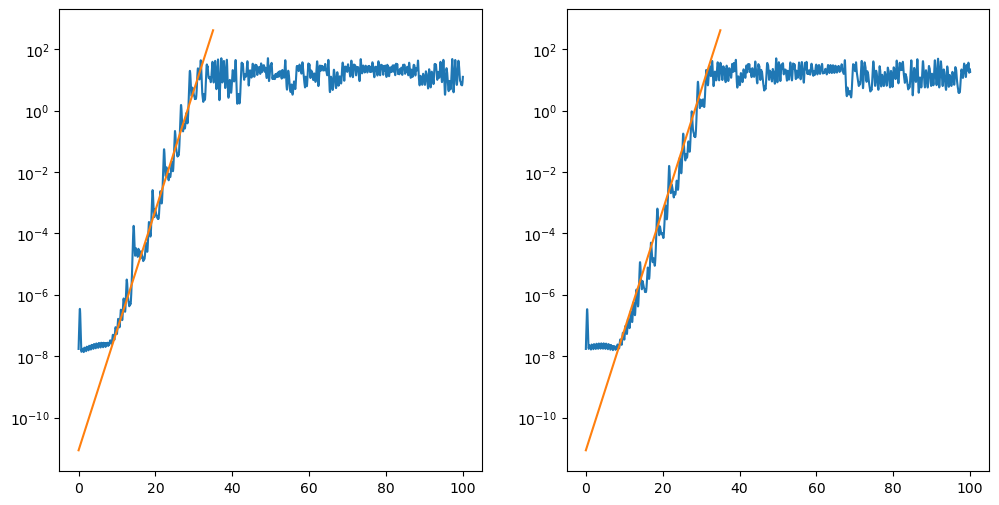

In [179]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.semilogy(t,deltaELR)
plt.semilogy(t[:35000], 0.0005*deltaELR[0]*np.exp(0.9*t[:35000]))

plt.subplot(1,2,2)
plt.semilogy(t,deltaRK4)
plt.semilogy(t[:35000], 0.0005*deltaELR[0]*np.exp(0.9*t[:35000]))


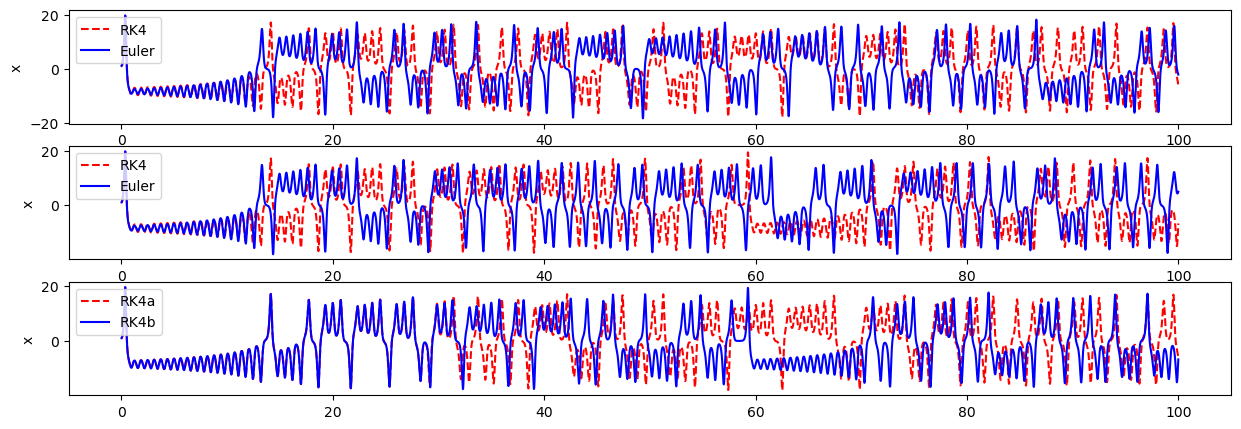

In [180]:
# compare solution for cross checking purpose

plt.figure(figsize=(15,5))
plt.subplot(3,1,1)
plt.plot(t, X1[0,:], 'r--', label='RK4')
plt.plot(t, Y1[0,:], 'b-', label='Euler')
plt.ylabel('x')
plt.legend()

plt.subplot(3,1,2)
plt.plot(t, X2[0,:], 'r--', label='RK4')
plt.plot(t, Y2[0,:], 'b-', label='Euler')
plt.ylabel('x')
plt.legend()

plt.subplot(3,1,3)
plt.plot(t, X1[0,:], 'r--', label='RK4a')
plt.plot(t, X2[0,:], 'b-' , label='RK4b')
plt.ylabel('x')
plt.legend()
